#  Telecom X – Predicción de Cancelación de Clientes (Churn)

**Proyecto de Machine Learning**  
**Autor:** Dan Satalaya

##  Objetivo
Construir modelos predictivos para identificar clientes con alta probabilidad de cancelar el servicio (churn) y extraer insights estratégicos para reducir la cancelación.

## 1️⃣ Carga de datos y revisión inicial
Se carga el dataset limpio de la Parte 1 y se revisa su estructura (columnas, tipos de datos y valores nulos).

In [30]:
import pandas as pd

df = pd.read_csv("telecomx_datos_limpios.csv")

print(df.head())
print(df.info())

   id_cliente Churn     genero  adulto_mayor tiene_pareja tiene_dependientes  \
0  0002-ORFBO    No   Femenino             0          Yes                Yes   
1  0003-MKNFE    No  Masculino             0           No                 No   
2  0004-TLHLJ   Yes  Masculino             0           No                 No   
3  0011-IGKFF   Yes  Masculino             1          Yes                 No   
4  0013-EXCHZ   Yes   Femenino             1          Yes                 No   

   antiguedad_meses servicio_telefono lineas_multiples servicio_internet  ...  \
0                 9               Yes               No               DSL  ...   
1                 9               Yes              Yes               DSL  ...   
2                 4               Yes               No      Fibra Óptica  ...   
3                13               Yes               No      Fibra Óptica  ...   
4                 3               Yes               No      Fibra Óptica  ...   

  respaldo_online proteccion_dis

## 2️⃣ Limpieza y preparación para modelado
Se realizan ajustes necesarios para que el dataset sea apto para Machine Learning:
- Eliminación de nulos en la variable objetivo (Churn)
- Eliminación de columna identificadora (id_cliente)
- Conversión de cargo_total a numérico
- Manejo de nulos generados por conversión

Nulos en Churn + drop

In [31]:
df["Churn"].isnull().sum()

np.int64(224)

In [32]:
df = df.dropna(subset=["Churn"])
df["Churn"].isnull().sum()

np.int64(0)

In [33]:
df.shape

(7043, 21)

Mapear Churn a 0-1

In [34]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [35]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [36]:
df.dtypes

,0
id_cliente,object
Churn,int64
genero,object
adulto_mayor,int64
tiene_pareja,object
tiene_dependientes,object
antiguedad_meses,int64
servicio_telefono,object
lineas_multiples,object
servicio_internet,object


Eliminar id_cliente

In [37]:
df = df.drop("id_cliente", axis=1)

In [38]:
df["cargo_total"].head(10)

,cargo_total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4
5,571.45
6,7904.25
7,5377.8
8,340.35
9,5957.9


Convertir cargo_total a numérico + limpiar nulos

In [39]:
df["cargo_total"] = pd.to_numeric(df["cargo_total"], errors="coerce")
df["cargo_total"].isnull().sum()

np.int64(11)

In [40]:
df = df.dropna(subset=["cargo_total"])
df["cargo_total"].isnull().sum()

np.int64(0)

In [41]:
df.shape

(7032, 20)

## 3️⃣ Codificación de variables categóricas (One-Hot Encoding)
Como los modelos de ML no interpretan texto directamente, se convierten variables categóricas a variables numéricas mediante One-Hot Encoding.
Se usa drop_first=True para evitar multicolinealidad en modelos lineales.

In [42]:
df = pd.get_dummies(df, drop_first=True)

In [43]:
df.head()
df.shape

(7032, 31)

In [44]:
df.dtypes

,0
Churn,int64
adulto_mayor,int64
antiguedad_meses,int64
cargo_mensual,float64
cargo_total,float64
genero_Masculino,bool
tiene_pareja_Yes,bool
tiene_dependientes_Yes,bool
servicio_telefono_Yes,bool
lineas_multiples_No phone service,bool


## 4️⃣ Distribución de clases (Churn)
Se calcula el porcentaje de clientes que cancelaron vs. los que permanecen.
Esto permite verificar el balance de clases (desbalance moderado).

Distribución churn %

In [45]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


## 5️⃣ Separación de datos (Train/Test)
Se separan variables predictoras (X) y variable objetivo (y).
Luego se divide el dataset en 80% entrenamiento y 20% prueba.
Se usa stratify=y para mantener la misma proporción de churn en ambos conjuntos.

X/y + split estratificado

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y.value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


In [47]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción en y_train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nProporción en y_test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)

Proporción en y_train (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Proporción en y_test (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


## 6️⃣ Modelo 1 – Regresión Logística
La Regresión Logística es un modelo base interpretativo para clasificación binaria.
Se aplica estandarización (StandardScaler) para mejorar convergencia y rendimiento.

Escalado

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Crear modelo
log_model = LogisticRegression(max_iter=1000)

# Entrenar
log_model.fit(X_train, y_train)

# Predecir
y_pred = log_model.predict(X_test)

# Evaluar
print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[923 110]
 [177 197]]


              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Entrenar y evaluar Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[928 105]
 [176 198]]


              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



## 7️⃣ Análisis de correlación
Se analiza la correlación de variables con Churn para identificar factores asociados a la cancelación.

Heatmap

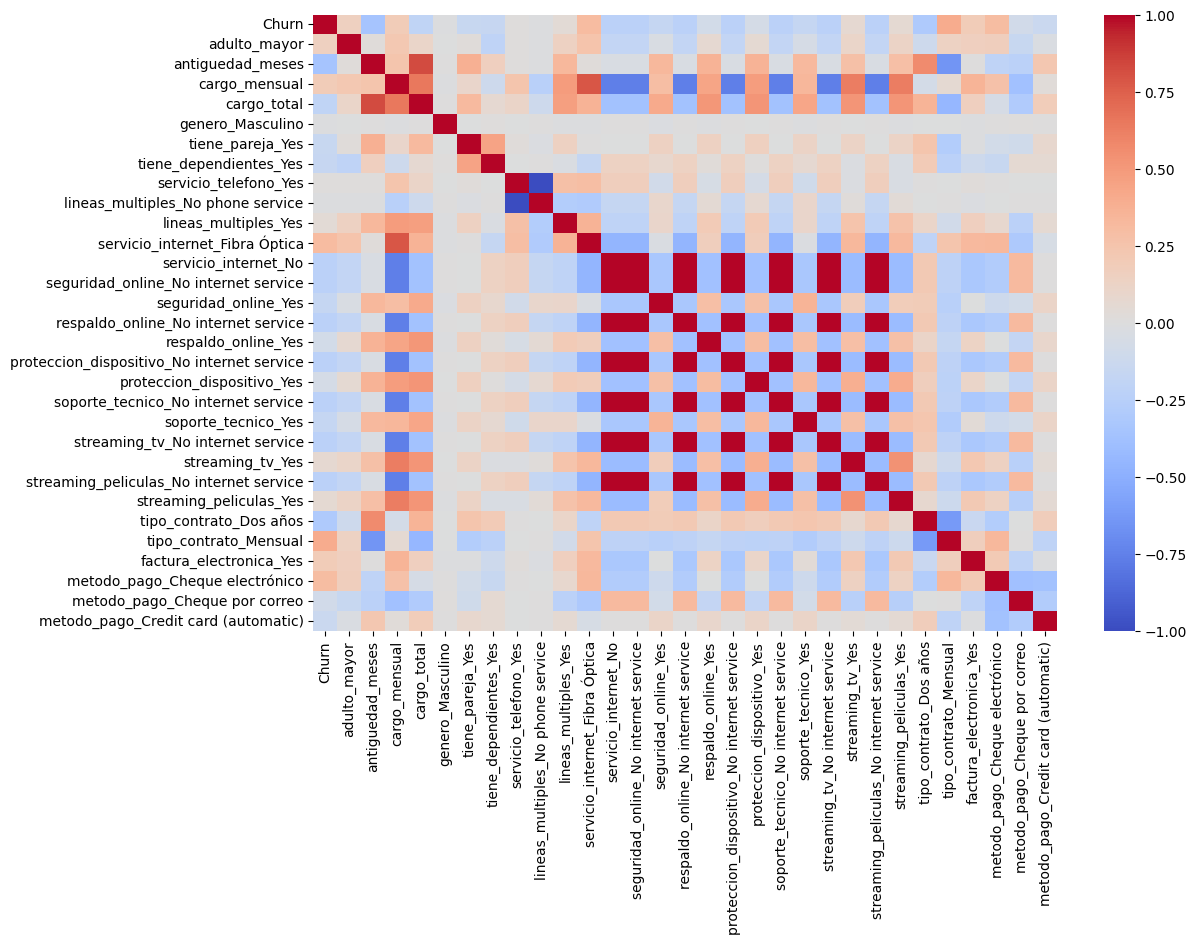

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.show()

Correlación con churn ordenada

In [53]:
corr = df.corr()

corr_churn = corr["Churn"].sort_values(ascending=False)

print(corr_churn)

Churn                                         1.000000
tipo_contrato_Mensual                         0.404565
servicio_internet_Fibra Óptica                0.307463
metodo_pago_Cheque electrónico                0.301455
cargo_mensual                                 0.192858
factura_electronica_Yes                       0.191454
adulto_mayor                                  0.150541
streaming_tv_Yes                              0.063254
streaming_peliculas_Yes                       0.060860
lineas_multiples_Yes                          0.040033
servicio_telefono_Yes                         0.011691
genero_Masculino                             -0.008545
lineas_multiples_No phone service            -0.011691
proteccion_dispositivo_Yes                   -0.066193
respaldo_online_Yes                          -0.082307
metodo_pago_Cheque por correo                -0.090773
metodo_pago_Credit card (automatic)          -0.134687
tiene_pareja_Yes                             -0.149982
tiene_depe

## 8️⃣ Modelo 2 – Random Forest
Se entrena Random Forest como segundo modelo para comparar desempeño.
Este modelo no requiere normalización.

Entrenar y evaluar RF

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenar (SIN escalado)
rf_model.fit(X_train, y_train)

# Predecir
y_pred_rf = rf_model.predict(X_test)

# Evaluar
print(confusion_matrix(y_test, y_pred_rf))
print("\n")
print(classification_report(y_test, y_pred_rf))

[[932 101]
 [200 174]]


              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



## 9️⃣ Interpretación de variables relevantes
Se interpretan:
- Coeficientes de Regresión Logística (impacto positivo-negativo en churn)
- Importancia de variables en Random Forest

Coeficientes Logística

In [55]:
import pandas as pd

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coeficiente", ascending=False)

print(coef_df.head(10))

                          Variable  Coeficiente
3                      cargo_total     0.612681
10  servicio_internet_Fibra Óptica     0.584425
25           tipo_contrato_Mensual     0.356543
21                streaming_tv_Yes     0.215796
26         factura_electronica_Yes     0.181409
27  metodo_pago_Cheque electrónico     0.168796
23         streaming_peliculas_Yes     0.146776
9             lineas_multiples_Yes     0.145638
0                     adulto_mayor     0.093639
17      proteccion_dispositivo_Yes     0.034521


In [56]:
coef_df.sort_values(by="Coeficiente").head(10)

,Variable,Coeficiente
1,antiguedad_meses,-1.312695
2,cargo_mensual,-0.526244
24,tipo_contrato_Dos años,-0.260844
19,soporte_tecnico_Yes,-0.162006
13,seguridad_online_Yes,-0.129687
11,servicio_internet_No,-0.072837
14,respaldo_online_No internet service,-0.072837
12,seguridad_online_No internet service,-0.072837
22,streaming_peliculas_No internet service,-0.072837
20,streaming_tv_No internet service,-0.072837


Importancia Random Forest

In [57]:
import pandas as pd

importances = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

print(importances.head(10))

                          Variable  Importancia
3                      cargo_total     0.186602
2                    cargo_mensual     0.170941
1                 antiguedad_meses     0.157948
25           tipo_contrato_Mensual     0.065365
27  metodo_pago_Cheque electrónico     0.038385
10  servicio_internet_Fibra Óptica     0.036791
4                 genero_Masculino     0.028889
26         factura_electronica_Yes     0.025189
13            seguridad_online_Yes     0.024909
5                 tiene_pareja_Yes     0.022642


## 🔟 Conclusión estratégica

###  Desempeño
- La **Regresión Logística** obtuvo mejor desempeño para la clase churn (mejor recall y F1).
- Random Forest fue competitivo pero detectó menos churners.

###  Factores que aumentan churn
- Contrato mensual
- Fibra óptica
- Cheque electrónico
- Cargos mensuales altos

###  Factores que reducen churn
- Mayor antigüedad del cliente (tenure)
- Contratos de largo plazo
- Servicios adicionales como soporte técnico y seguridad online

###  Recomendaciones
- Incentivar contratos anuales / dos años
- Programas de retención temprana para clientes nuevos
- Revisar experiencia y soporte para usuarios de fibra óptica